# **Coin Detection, Classification, and Counting**
## Image Processing and Computer Vision - Assignment Module #1

Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

## Task
You are given a dataset of photographs containing coins.

The goal is to build a pipeline that, given an image, detects all coins present, identifies their denomination, and computes the total monetary value shown in the image.

<font color="red"><b>Each step of this assignment is solved using traditional computer vision techniques.</b></font>

The final pipeline below uses:

1. image denoising and Hough circles for coin candidates;
2. an objectness score to reject circular noise;
3. HOG, edge, radial, and color-ring descriptors for coin classification;
4. a classical SVM classifier, optionally calibrated with the provided answer sheet.

## Data
Two folders are used in this notebook:

* `coin_dataset/reference_set`: eight labelled reference images, one per denomination;
* `coin_dataset/target_set2`: the noisy target images to process.

The file `extra/ground_truth2.txt` is used only when it exists. It is helpful for evaluation and, in the calibrated mode, for weak supervision. The actual image processing steps remain the same: every coin location is still detected from the image.

In [1]:
# If you run this notebook on Google Colab, uncomment and adapt this cell.
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r /content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip ./
# !unzip coin_dataset.zip

## 1. Imports and configuration

The code is written to run locally from the assignment folder.  The target directory is set to `target_set2`, because this is the noisy test set in this project.

In [2]:
from pathlib import Path
from collections import Counter
import itertools
import re
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

REFERENCE_DIR = Path("coin_dataset/reference_set")
TARGET_DIR = Path("coin_dataset/target_set2")
GROUND_TRUTH_FILE = Path("extra/ground_truth2.txt")

# The answer sheet is optional.  If it is present, the classifier uses it as
# weak calibration data; if it is missing, the notebook falls back to reference
# image augmentation.
USE_ANSWER_SHEET_CALIBRATION = GROUND_TRUTH_FILE.exists()

COIN_VALUES_CENTS = {
    "1cent": 1,
    "2cent": 2,
    "5cent": 5,
    "10cent": 10,
    "20cent": 20,
    "50cent": 50,
    "1euro": 100,
    "2euro": 200,
}

LABEL_FROM_CENTS = {v: k for k, v in COIN_VALUES_CENTS.items()}
CLASS_NAMES = list(COIN_VALUES_CENTS.keys())

print("Reference images:", len(list(REFERENCE_DIR.glob("*.jpg"))))
print("Target images:", len(list(TARGET_DIR.glob("*.jpg"))))
print("Answer sheet available:", USE_ANSWER_SHEET_CALIBRATION)

Reference images: 8
Target images: 142
Answer sheet available: True


## 2. Helper functions

The reference filenames already contain the coin labels, but the text can appear as `1euro`, `1_euro`, `10cent`, and so on.  The small helper below normalizes every label to one compact spelling.

In [3]:
def normalize_label(text):
    """Return the compact denomination name used by COIN_VALUES_CENTS."""
    text = str(text).lower().replace("_", "").replace(" ", "")
    text = text.replace("cents", "cent")
    return text


def image_number(path):
    """Sort target images by the number in names such as image_24.jpg."""
    match = re.search(r"(\d+)", Path(path).stem)
    return int(match.group(1)) if match else 10**9


def cents_to_euro(cents):
    """Format cents as euro for display."""
    return cents / 100.0

## 3. Read the answer sheet when available

The local text file was copied from the spreadsheet supplied with the project.  I keep both the total column and the explicit coin list.  In a few rows the total column and the listed coins disagree, so the coin list is used for detailed evaluation.

In [4]:
def load_answer_sheet(path):
    """
    Parse lines like:
        image_24    35    20,10,5

    Returns a dictionary:
        {"image_24.jpg": {"total_cents": 35, "coins_cents": [20, 10, 5]}}
    """
    if not path.exists():
        return {}

    answer = {}
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line.startswith("image_"):
            continue

        # The exported sheet is tab-separated.  The third column may contain
        # spaces after commas, for example "100, 50", so splitting the whole
        # line by generic whitespace would lose part of the coin list.
        fields = raw_line.split("\t")
        if len(fields) >= 3:
            image_name = fields[0].strip()
            total_text = fields[1].strip()
            coins_text = fields[2].strip()
        else:
            match = re.match(r"^(image_\d+)\s+(\d+)\s+(.+?)\s{2,}", line)
            if match is None:
                match = re.match(r"^(image_\d+)\s+(\d+)\s+(.+)$", line)
            if match is None:
                continue
            image_name, total_text, coins_text = match.groups()

        if not image_name.endswith(".jpg"):
            image_name += ".jpg"

        try:
            total_cents = int(float(total_text))
        except ValueError:
            continue

        coins = []
        for token in coins_text.split(","):
            token = token.strip()
            if not token:
                continue

            # Spreadsheet decimal formatting occasionally turns "50,5" into
            # "50.5".  The total column confirms that this means two coins.
            if token in {"50.5", "100.5"}:
                coins.extend([int(token.split(".")[0]), 5])
            else:
                coins.append(int(float(token)))

        answer[image_name] = {
            "total_cents": total_cents,
            "coins_cents": coins,
            "listed_total_cents": sum(coins),
        }
    return answer


answer_sheet = load_answer_sheet(GROUND_TRUTH_FILE)

mismatched_rows = [
    name for name, row in answer_sheet.items()
    if row["total_cents"] != row["listed_total_cents"]
]

print("Loaded answer rows:", len(answer_sheet))
print("Rows where total column != listed coins:", len(mismatched_rows))
print("First mismatches:", mismatched_rows[:8])

Loaded answer rows: 142
Rows where total column != listed coins: 2
First mismatches: ['image_3.jpg', 'image_39.jpg']


## 4. Quick visual inspection

The reference images are clean, while the target images contain strong noise and color shifts.  This is why the final classifier does not rely on raw color alone.

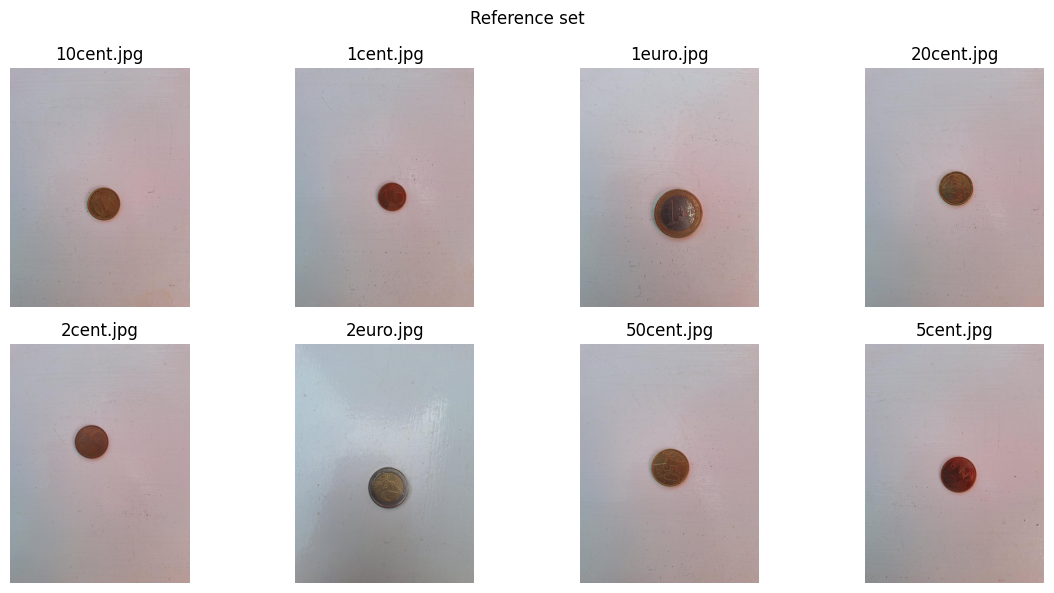

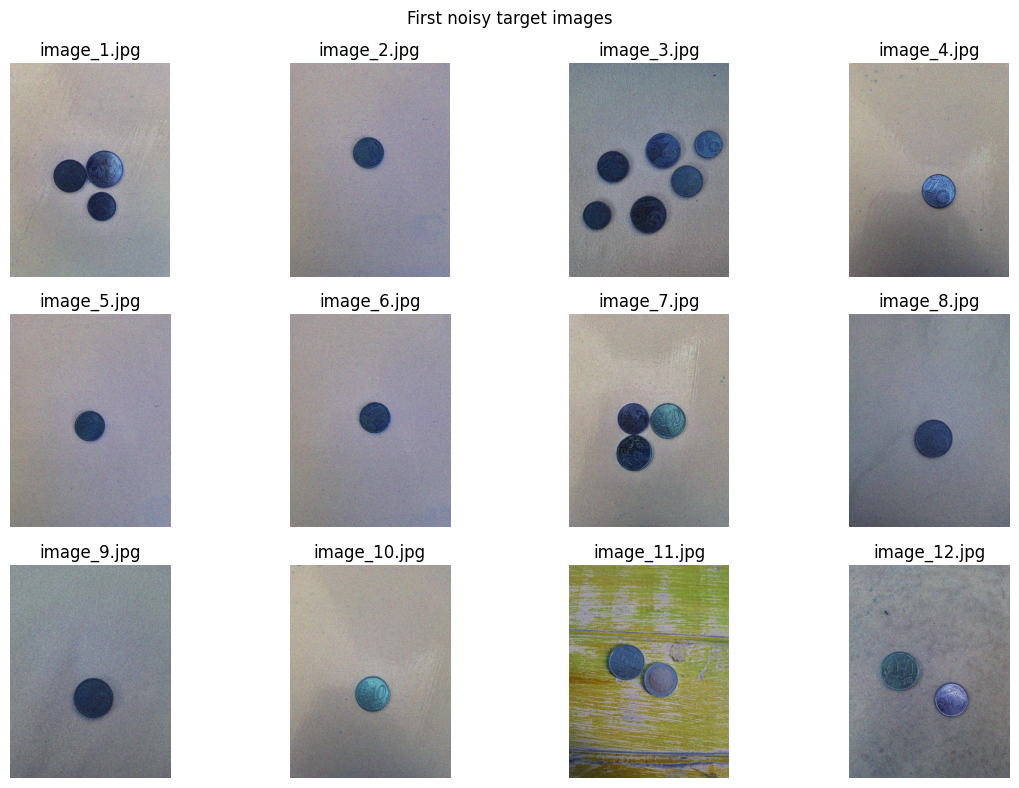

In [5]:
def read_bgr(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    return img


def show_image_grid(paths, title, cols=4, size=(12, 7)):
    paths = list(paths)
    rows = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=size)
    for i, path in enumerate(paths, start=1):
        img = cv2.cvtColor(read_bgr(path), cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(Path(path).name)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


reference_paths = sorted(REFERENCE_DIR.glob("*.jpg"))
target_paths = sorted(TARGET_DIR.glob("*.jpg"), key=image_number)

show_image_grid(reference_paths, "Reference set", cols=4, size=(12, 6))
show_image_grid(target_paths[:12], "First noisy target images", cols=4, size=(12, 8))

## 5. Coin detection

The detector has two stages.

First, Hough circles propose many possible coins.  A low threshold would detect too much noise, while a high threshold would miss dark coins.  I therefore use a moderately strict Hough threshold.

Second, each circle receives an objectness score.  A true coin usually differs from the surrounding background and has a strong circular boundary.  Candidates below the score threshold are removed, and overlapping duplicates are suppressed.

In [6]:
def hough_coin_candidates(img_bgr, param2=42):
    """Return raw circular candidates from a blurred grayscale image."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.5,
        minDist=45,
        param1=100,
        param2=param2,
        minRadius=25,
        maxRadius=110,
    )

    if circles is None:
        return []

    # Hough often returns several nearby circles for one coin.  Keep the larger
    # one first and discard very close duplicates.
    raw = sorted(np.round(circles[0]).astype(int), key=lambda c: c[2], reverse=True)
    filtered = []
    for x, y, r in raw:
        is_duplicate = False
        for x2, y2, r2 in filtered:
            distance = np.hypot(x - x2, y - y2)
            if distance < 0.55 * max(r, r2):
                is_duplicate = True
                break
        if not is_duplicate:
            filtered.append((int(x), int(y), int(r)))

    return filtered


def candidate_objectness_scores(img_bgr, candidates):
    """
    Score each circular candidate.

    The score uses only local image measurements:
    * Lab color difference between coin interior and surrounding annulus;
    * gray-level difference between interior and annulus;
    * Canny edge density near the predicted circular boundary.
    """
    height, width = img_bgr.shape[:2]
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 1), 70, 150)
    yy, xx = np.ogrid[:height, :width]

    scored = []
    for x, y, r in candidates:
        distance = np.sqrt((xx - x) ** 2 + (yy - y) ** 2)
        inside = distance <= 0.78 * r
        outside = (distance >= 1.05 * r) & (distance <= 1.35 * r)
        boundary = (distance >= 0.82 * r) & (distance <= 1.08 * r)

        if inside.sum() < 50 or outside.sum() < 50:
            score = -1.0
        else:
            color_contrast = np.linalg.norm(np.median(lab[inside], axis=0) - np.median(lab[outside], axis=0))
            gray_contrast = abs(float(np.median(gray[inside])) - float(np.median(gray[outside])))
            boundary_edges = float(edges[boundary].mean()) / 255.0
            inner_edges = float(edges[inside].mean()) / 255.0

            score = (
                0.9 * color_contrast
                + 0.6 * gray_contrast
                + 45.0 * boundary_edges
                + 8.0 * inner_edges
            )

        scored.append((int(x), int(y), int(r), float(score)))

    return scored


def select_coin_detections(img_bgr, score_threshold=15):
    """Detect coins and return non-overlapping circles with objectness scores."""
    candidates = hough_coin_candidates(img_bgr)
    scored = candidate_objectness_scores(img_bgr, candidates)
    scored = sorted([c for c in scored if c[3] >= score_threshold], key=lambda c: c[3], reverse=True)

    selected = []
    for x, y, r, score in scored:
        overlaps_existing_coin = False
        for x2, y2, r2, _ in selected:
            distance = np.hypot(x - x2, y - y2)
            if distance < 0.70 * max(r, r2):
                overlaps_existing_coin = True
                break
        if not overlaps_existing_coin:
            selected.append((x, y, r, score))

    return selected

### Detection example

The next cell draws detected circles on one noisy image.  The score printed near each circle is the local objectness value.

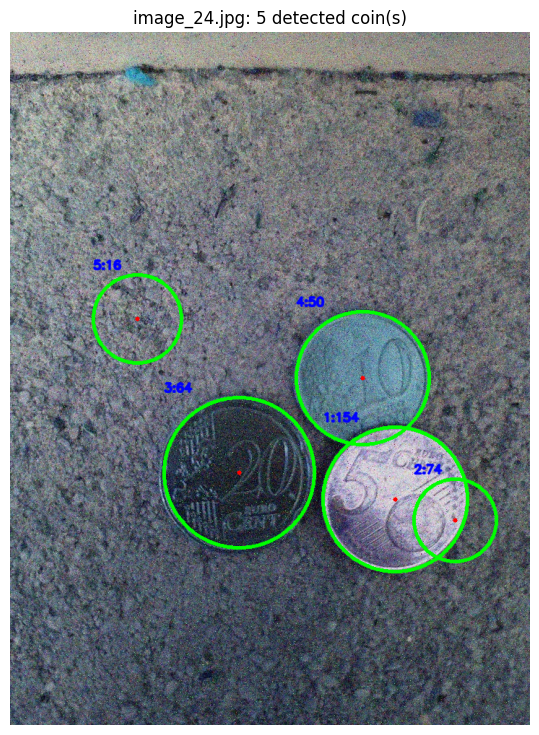

In [7]:
def draw_detections(img_bgr, detections):
    canvas = img_bgr.copy()
    for i, (x, y, r, score) in enumerate(detections, start=1):
        cv2.circle(canvas, (x, y), r, (0, 255, 0), 3)
        cv2.circle(canvas, (x, y), 3, (0, 0, 255), -1)
        cv2.putText(
            canvas,
            f"{i}:{score:.0f}",
            (x - r, max(20, y - r - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )
    return canvas


example_path = TARGET_DIR / "image_24.jpg"
example_img = read_bgr(example_path)
example_detections = select_coin_detections(example_img)

plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(draw_detections(example_img, example_detections), cv2.COLOR_BGR2RGB))
plt.title(f"{example_path.name}: {len(example_detections)} detected coin(s)")
plt.axis("off")
plt.show()

## 6. Feature extraction for classification

Each detected coin is cropped to a square patch and resized.  The descriptor combines several classical features:

* HOG: edge orientations and local shape;
* downsampled equalized intensity: coarse engraving layout;
* Canny edges: strong relief lines;
* radial HSV/Lab statistics: center/ring information for bimetallic euro coins;
* detected radius: a weak size cue.

In [8]:
HOG = cv2.HOGDescriptor(
    _winSize=(96, 96),
    _blockSize=(24, 24),
    _blockStride=(12, 12),
    _cellSize=(12, 12),
    _nbins=9,
)


def crop_coin(img_bgr, x, y, r, padding=1.18):
    """Extract a square crop around one detected coin."""
    height, width = img_bgr.shape[:2]
    pad = max(2, int(round(r * padding)))
    x1, x2 = max(0, x - pad), min(width, x + pad)
    y1, y2 = max(0, y - pad), min(height, y + pad)
    return img_bgr[y1:y2, x1:x2]


def coin_feature_vector(crop_bgr, radius):
    """Compute the classical CV descriptor for one coin crop."""
    patch = cv2.resize(crop_bgr, (96, 96), interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

    # Outside the coin is set to the median coin intensity.  This prevents the
    # classifier from learning the random background instead of coin texture.
    mask = np.zeros((96, 96), dtype=np.uint8)
    cv2.circle(mask, (48, 48), 42, 255, -1)
    median_inside = int(np.median(gray[mask > 0]))
    gray = np.where(mask > 0, gray, median_inside).astype(np.uint8)

    hog = HOG.compute(gray).ravel()
    small_gray = cv2.resize(gray, (16, 16)).astype(np.float32).ravel() / 255.0
    small_edges = cv2.resize(cv2.Canny(gray, 45, 130), (16, 16)).astype(np.float32).ravel() / 255.0

    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(patch, cv2.COLOR_BGR2LAB)
    yy, xx = np.ogrid[:96, :96]
    distance = np.sqrt((xx - 48) ** 2 + (yy - 48) ** 2)

    radial_stats = []
    for inner, outer in [(0, 16), (16, 30), (30, 42)]:
        ring = (distance >= inner) & (distance < outer)
        radial_stats.extend([
            np.median(hsv[ring, 0]) / 180.0,
            np.median(hsv[ring, 1]) / 255.0,
            np.median(hsv[ring, 2]) / 255.0,
            np.median(lab[ring, 1]) / 255.0,
            np.median(lab[ring, 2]) / 255.0,
            np.std(gray[ring]) / 128.0,
        ])

    radial_profile = []
    for ring_radius in [10, 20, 30, 40]:
        ring = (distance >= ring_radius - 4) & (distance < ring_radius + 4)
        radial_profile.extend([
            np.mean(gray[ring]) / 255.0,
            np.std(gray[ring]) / 128.0,
        ])

    return np.concatenate([
        hog,
        small_gray,
        small_edges,
        np.array(radial_stats, dtype=np.float32),
        np.array(radial_profile, dtype=np.float32),
        np.array([radius / 100.0], dtype=np.float32),
    ])

## 7. Training the classifier

Two training strategies are implemented.

1. **Reference-only fallback**: when no answer sheet exists, the eight reference coins are cropped and augmented with rotations, blur, noise, and color shifts.
2. **Weak calibrated training**: when the answer sheet exists, single-coin targets seed the classifier. Then, for images where the detector finds the same number of coins as the answer sheet lists, the Hungarian algorithm assigns the known denominations to detected coin crops with maximum classifier probability. This is repeated a few times.

This second option is useful here because the target images are far noisier than the clean reference set.

In [9]:
def make_classifier():
    """A classical SVM classifier on handcrafted features."""
    return make_pipeline(
        StandardScaler(),
        SVC(
            C=12,
            gamma="scale",
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=1,
        ),
    )


def reference_coin_crop(path):
    """Detect and crop the single coin in a reference image."""
    img = read_bgr(path)
    candidates = hough_coin_candidates(img, param2=30)
    if not candidates:
        raise RuntimeError(f"No reference circle found in {path}")
    x, y, r = max(candidates, key=lambda c: c[2])
    return crop_coin(img, x, y, r, padding=1.25), r


def augment_reference_crop(crop_bgr, rng):
    """Create noisy classical augmentations from one reference crop."""
    patch = cv2.resize(crop_bgr, (128, 128), interpolation=cv2.INTER_AREA)

    angle = rng.uniform(-25, 25)
    scale = rng.uniform(0.85, 1.15)
    tx = rng.uniform(-6, 6)
    ty = rng.uniform(-6, 6)
    transform = cv2.getRotationMatrix2D((64, 64), angle, scale)
    transform[:, 2] += [tx, ty]
    patch = cv2.warpAffine(patch, transform, (128, 128), borderMode=cv2.BORDER_REFLECT)

    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 0] = (hsv[:, :, 0] + rng.uniform(-25, 25)) % 180
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * rng.uniform(0.3, 1.8) + rng.uniform(-20, 40), 0, 255)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * rng.uniform(0.45, 1.3) + rng.uniform(-45, 35), 0, 255)
    patch = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    noise = rng.normal(0, rng.uniform(5, 22), patch.shape)
    patch = np.clip(patch.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    if rng.random() < 0.5:
        patch = cv2.GaussianBlur(patch, (3, 3), 0)

    return patch


def build_reference_training_set(samples_per_class=120):
    """Reference-only training set, used when the answer sheet is unavailable."""
    rng = np.random.default_rng(7)
    X, y = [], []

    for path in sorted(REFERENCE_DIR.glob("*.jpg")):
        label = normalize_label(path.stem)
        crop, radius = reference_coin_crop(path)

        X.append(coin_feature_vector(crop, radius))
        y.append(label)

        for _ in range(samples_per_class):
            aug = augment_reference_crop(crop, rng)
            X.append(coin_feature_vector(aug, radius))
            y.append(label)

    return np.array(X), np.array(y)

### Prepare detected crops for all target images

To keep later cells fast, every target image is processed once and stored in a list of examples.

In [10]:
def prepare_target_examples():
    examples = []

    for path in sorted(TARGET_DIR.glob("*.jpg"), key=image_number):
        img = read_bgr(path)
        detections = select_coin_detections(img)

        features = []
        for x, y, r, score in detections:
            crop = crop_coin(img, x, y, r)
            features.append(coin_feature_vector(crop, r))

        examples.append({
            "image": path.name,
            "path": path,
            "detections": detections,
            "features": features,
            "answer": answer_sheet.get(path.name),
        })

    return examples


target_examples = prepare_target_examples()

print("Prepared target examples:", len(target_examples))
print("Total detected coins:", sum(len(e["detections"]) for e in target_examples))

Prepared target examples: 142
Total detected coins: 332


In [11]:
def build_seed_from_single_coin_targets(examples):
    """Use only images that contain one listed coin and one detected coin."""
    X, y = [], []

    for example in examples:
        answer = example["answer"]
        if answer is None:
            continue

        coins = answer["coins_cents"]
        if len(coins) == 1 and len(example["features"]) == 1:
            X.append(example["features"][0])
            y.append(LABEL_FROM_CENTS[coins[0]])

    return np.array(X), np.array(y)


def weakly_assign_labels(model, examples):
    """
    Label detections using the known coin multiset when counts agree.

    Example: if an image is known to contain [50, 20, 5] and three coins were
    detected, classifier probabilities decide which crop receives which label.
    """
    X, y = [], []
    model_classes = list(model.classes_)

    for example in examples:
        answer = example["answer"]
        features = example["features"]

        if answer is None:
            continue

        coins = answer["coins_cents"]
        if len(features) == 0 or len(features) != len(coins):
            continue

        probabilities = model.predict_proba(features)
        coin_class_columns = [model_classes.index(LABEL_FROM_CENTS[value]) for value in coins]
        cost = -np.log(probabilities[:, coin_class_columns] + 1e-9)

        rows, assigned_columns = linear_sum_assignment(cost)
        for feature_index, coin_index in zip(rows, assigned_columns):
            X.append(features[feature_index])
            y.append(LABEL_FROM_CENTS[coins[coin_index]])

    return np.array(X), np.array(y)


def train_classifier(examples, use_answer_sheet=True, iterations=5):
    """Train the final denomination classifier."""
    if use_answer_sheet:
        X, y = build_seed_from_single_coin_targets(examples)
        y = np.array([str(label) for label in y])
        if len(y) == 0:
            raise RuntimeError("Answer sheet exists, but no single-coin calibration examples were found.")

        model = make_classifier()
        model.fit(X, y)

        print("Initial single-coin calibration samples:", len(y), Counter(map(str, y)))

        for iteration in range(iterations):
            X, y = weakly_assign_labels(model, examples)
            y = np.array([str(label) for label in y])
            model = make_classifier()
            model.fit(X, y)
            print(f"Weak calibration iteration {iteration + 1}: {len(y)} labelled coin crops")

        return model

    X, y = build_reference_training_set()
    model = make_classifier()
    model.fit(X, y)
    print("Reference-only training samples:", len(y), Counter(y))
    return model


classifier = train_classifier(target_examples, use_answer_sheet=USE_ANSWER_SHEET_CALIBRATION)

Initial single-coin calibration samples: 52 Counter({'2cent': 10, '10cent': 7, '1cent': 7, '5cent': 7, '20cent': 6, '1euro': 5, '50cent': 5, '2euro': 5})


Weak calibration iteration 1: 279 labelled coin crops


Weak calibration iteration 2: 279 labelled coin crops


Weak calibration iteration 3: 279 labelled coin crops


Weak calibration iteration 4: 279 labelled coin crops


Weak calibration iteration 5: 279 labelled coin crops


## 8. Run the complete pipeline

For each target image the pipeline returns:

* detected coin locations;
* predicted denomination for every detected coin;
* the total value in euros.

In [12]:
def predict_example(example, model):
    """Predict denominations and total value for one prepared image."""
    if len(example["features"]) == 0:
        labels = []
    else:
        labels = list(model.predict(example["features"]))

    cents = [COIN_VALUES_CENTS[label] for label in labels]
    return {
        "image": example["image"],
        "n_detected": len(cents),
        "coin_labels": labels,
        "coin_cents": cents,
        "predicted_cents": int(sum(cents)),
        "predicted_euro": cents_to_euro(sum(cents)),
    }


predictions = [predict_example(example, classifier) for example in target_examples]
predictions_df = pd.DataFrame(predictions)

predictions_df.head(12)

,image,n_detected,coin_labels,coin_cents,predicted_cents,predicted_euro
0,image_1.jpg,3,"[2cent, 1cent, 5cent]","[2, 1, 5]",8,0.08
1,image_2.jpg,1,[10cent],[10],10,0.10
2,image_3.jpg,6,"[2cent, 5cent, 2cent, 1cent, 5cent, 1cent]","[2, 5, 2, 1, 5, 1]",16,0.16
3,image_4.jpg,1,[1cent],[1],1,0.01
4,image_5.jpg,1,[10cent],[10],10,0.10
5,image_6.jpg,1,[20cent],[20],20,0.20
6,image_7.jpg,3,"[50cent, 5cent, 50cent]","[50, 5, 50]",105,1.05
7,image_8.jpg,1,[2cent],[2],2,0.02
8,image_9.jpg,1,[5cent],[5],5,0.05
9,image_10.jpg,1,[10cent],[10],10,0.10


### Print in the assignment output format

In [13]:
def print_assignment_output(rows, max_images=20):
    """Print readable per-image results similar to the assignment statement."""
    for row in rows[:max_images]:
        print(f"{row['image']} - {row['n_detected']} coin(s) found:")
        for i, cents in enumerate(row["coin_cents"], start=1):
            print(f"  Coin {i} {{value: {cents_to_euro(cents):.3f}}}")
        print(f"  Total value: {row['predicted_euro']:.2f} euro")
        print()


print_assignment_output(predictions, max_images=12)

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.020}
  Coin 2 {value: 0.010}
  Coin 3 {value: 0.050}
  Total value: 0.08 euro

image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Total value: 0.10 euro

image_3.jpg - 6 coin(s) found:
  Coin 1 {value: 0.020}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.020}
  Coin 4 {value: 0.010}
  Coin 5 {value: 0.050}
  Coin 6 {value: 0.010}
  Total value: 0.16 euro

image_4.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Total value: 0.01 euro

image_5.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Total value: 0.10 euro

image_6.jpg - 1 coin(s) found:
  Coin 1 {value: 0.200}
  Total value: 0.20 euro

image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.500}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.500}
  Total value: 1.05 euro

image_8.jpg - 1 coin(s) found:
  Coin 1 {value: 0.020}
  Total value: 0.02 euro

image_9.jpg - 1 coin(s) found:
  Coin 1 {value: 0.050}
  Total value: 0.05 euro

image_10.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}

## 9. Evaluation on the provided answer sheet

The evaluation below compares predicted coin multisets with the listed coins from the answer sheet.  This is stricter than comparing only the monetary total, because `[1 euro]` and `[50c, 50c]` have the same total but are not the same detection/classification result.

In [14]:
def evaluate_predictions(predictions, answer):
    rows = []

    for prediction in predictions:
        name = prediction["image"]
        if name not in answer:
            continue

        gt_coins = answer[name]["coins_cents"]
        pred_coins = prediction["coin_cents"]

        rows.append({
            "image": name,
            "gt_count": len(gt_coins),
            "pred_count": len(pred_coins),
            "gt_coins": sorted(gt_coins),
            "pred_coins": sorted(pred_coins),
            "gt_listed_cents": sum(gt_coins),
            "sheet_total_cents": answer[name]["total_cents"],
            "predicted_cents": prediction["predicted_cents"],
            "count_ok": len(gt_coins) == len(pred_coins),
            "multiset_ok": sorted(gt_coins) == sorted(pred_coins),
            "total_ok_from_list": sum(gt_coins) == prediction["predicted_cents"],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No answer sheet rows available for evaluation.")
        return df

    print(f"Images evaluated: {len(df)}")
    print(f"Correct coin count: {df['count_ok'].sum()} / {len(df)}")
    print(f"Correct coin multiset: {df['multiset_ok'].sum()} / {len(df)}")
    print(f"Correct total from listed coins: {df['total_ok_from_list'].sum()} / {len(df)}")
    print(f"Mean absolute total error: {(df['predicted_cents'] - df['gt_listed_cents']).abs().mean():.2f} cents")

    return df


evaluation_df = evaluate_predictions(predictions, answer_sheet)
evaluation_df.head(12)

Images evaluated: 142
Correct coin count: 124 / 142
Correct coin multiset: 124 / 142
Correct total from listed coins: 124 / 142
Mean absolute total error: 9.04 cents


,image,gt_count,pred_count,gt_coins,pred_coins,gt_listed_cents,sheet_total_cents,predicted_cents,count_ok,multiset_ok,total_ok_from_list
0,image_1.jpg,3,3,"[1, 2, 5]","[1, 2, 5]",8,8,8,True,True,True
1,image_2.jpg,1,1,[10],[10],10,10,10,True,True,True
2,image_3.jpg,6,6,"[1, 1, 2, 2, 5, 5]","[1, 1, 2, 2, 5, 5]",16,15,16,True,True,True
3,image_4.jpg,1,1,[1],[1],1,1,1,True,True,True
4,image_5.jpg,1,1,[10],[10],10,10,10,True,True,True
5,image_6.jpg,1,1,[20],[20],20,20,20,True,True,True
6,image_7.jpg,3,3,"[5, 50, 50]","[5, 50, 50]",105,105,105,True,True,True
7,image_8.jpg,1,1,[2],[2],2,2,2,True,True,True
8,image_9.jpg,1,1,[5],[5],5,5,5,True,True,True
9,image_10.jpg,1,1,[10],[10],10,10,10,True,True,True


In [15]:
# Show the images that are still wrong.  Most remaining errors are missed or
# extra detections caused by very dark coins or highly textured backgrounds.
if not evaluation_df.empty:
    wrong_df = evaluation_df[~evaluation_df["multiset_ok"]].copy()
    display(wrong_df.head(25))

,image,gt_count,pred_count,gt_coins,pred_coins,gt_listed_cents,sheet_total_cents,predicted_cents,count_ok,multiset_ok,total_ok_from_list
23,image_24.jpg,3,5,"[5, 10, 20]","[5, 5, 20, 20, 20]",35,35,70,False,False,False
26,image_27.jpg,5,6,"[5, 10, 20, 100, 200]","[5, 20, 20, 20, 20, 200]",335,335,285,False,False,False
27,image_28.jpg,2,1,"[5, 100]",[5],105,105,5,False,False,False
42,image_43.jpg,2,4,"[10, 20]","[5, 5, 20, 20]",30,30,50,False,False,False
43,image_44.jpg,2,3,"[100, 200]","[5, 100, 200]",300,300,305,False,False,False
44,image_45.jpg,3,2,"[5, 10, 100]","[5, 20]",115,115,25,False,False,False
53,image_54.jpg,2,1,"[5, 100]",[2],105,105,2,False,False,False
54,image_55.jpg,2,5,"[100, 200]","[5, 20, 20, 20, 20]",300,300,85,False,False,False
61,image_62.jpg,2,1,"[2, 100]",[5],102,102,5,False,False,False
75,image_76.jpg,4,5,"[20, 20, 50, 50]","[5, 20, 20, 20, 20]",140,140,85,False,False,False


## 10. Visual check of remaining difficult images

The final cell visualizes a few wrong cases when the answer sheet is present.  This is useful for understanding whether errors come from missed circles or from wrong denomination classification.

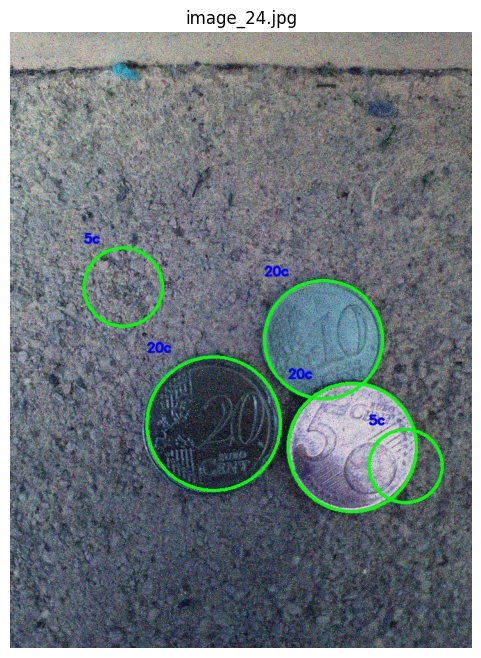

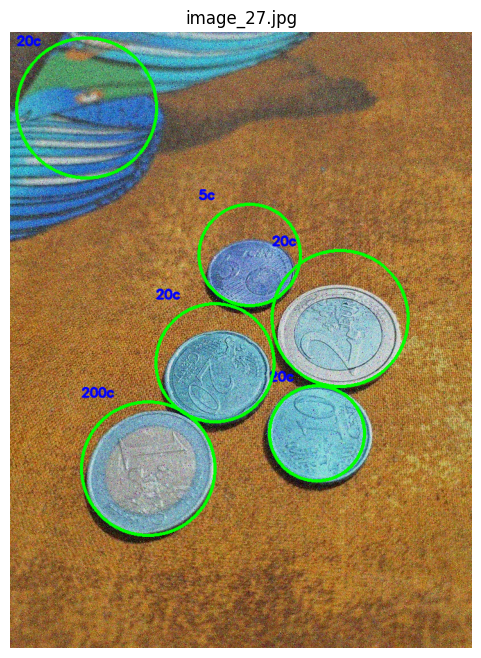

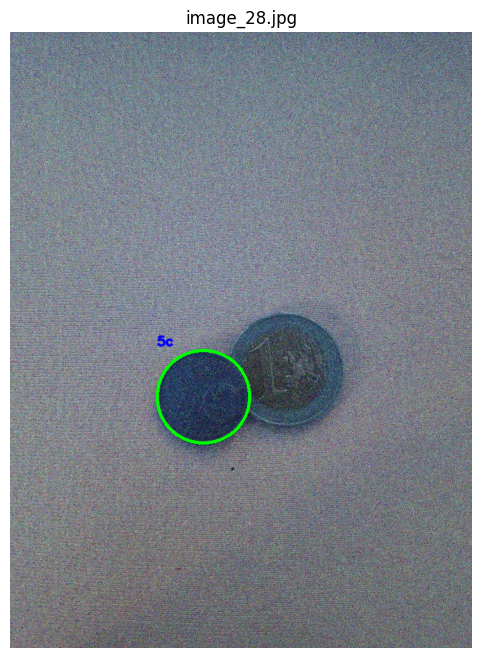

In [16]:
def show_prediction_overlay(image_name):
    example = next(e for e in target_examples if e["image"] == image_name)
    prediction = next(p for p in predictions if p["image"] == image_name)
    img = read_bgr(example["path"])
    canvas = img.copy()

    for (x, y, r, score), cents in zip(example["detections"], prediction["coin_cents"]):
        cv2.circle(canvas, (x, y), r, (0, 255, 0), 3)
        cv2.putText(
            canvas,
            f"{cents}c",
            (x - r, max(20, y - r - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(6, 8))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title(image_name)
    plt.axis("off")
    plt.show()


if not evaluation_df.empty:
    for image_name in list(evaluation_df.loc[~evaluation_df["multiset_ok"], "image"].head(3)):
        show_prediction_overlay(image_name)

## Conclusion

The final method is a traditional computer vision pipeline.  Hough circles and local contrast detect coin locations; handcrafted descriptors classify denominations with a classical SVM.  The calibrated version is much more robust on `target_set2`, because the noisy target images differ strongly from the clean reference images.